   # GA applied to OneMax

This notebook implements a simple GA in a fairly lowlevel way. In later examples we'll use more highlevel operators, but it is a very valuable exercise to ensure you understand what this code is actually doing. Make sure you understand the processes below before moving to the more high-level toolboxes!

Install DEAP. Note that if you are running this on your own computer you might not need to do this. In fact, it is better practice to install it so that it is always available, but when running on Colab, we do need this.

# QUESTION 1: Roulette wheel selection, individual size 50
#
# ANSWER: the smallest number of individuals processed I found is 8,280
#   (population size 120 x 69 generations), crossover 0.9, mutation 0.01, seed 9.
#   The next best was 9,100 (population 100 x 91 generations, crossover 0.7, mutation 0.01).
#
# That best run was lucky: its setup solved only 1 of 10 seeds. A setup that
#   solves it reliably is population 120-150, crossover 0.9, mutation 0.1
#   (9/10 and 10/10 runs solved, best 11,880 and 13,800).
#
# Other setups tried (10 seeds each, max 300 generations, see cells below):
#   * Population size (crossover 0.7, mutation 0.01): populations of 20, 50 and 80
#     never found the perfect solution. 100 solved 1/10, 150 solved 4/10,
#     200 solved 5/10, 300 solved 10/10. Roulette needs a population of about 100+.
#   * Mutation 0.1 helped a lot (e.g. population 120: 0/10 -> 9/10 solved),
#     because it puts back 1s that are lost. Mutation 0.5 always failed (0/10):
#     roulette selection is too weak to keep up with that much disruption.
#   * Crossover 0.9 or 1.0 was usually a bit better than 0.7.
#
# Why roulette needs so much: selection chance is proportional to fitness.
#   Near the end every individual scores 45 to 50, so the best one is barely
#   more likely to be picked than the rest, and with no elitism it is often
#   lost (the max fitness goes up and down in the run above).
#
# Change to the original notebook: the clone line after selection was
#   uncommented, so an individual selected twice is copied, not shared.

In [1]:
!pip install deap

Import the DEAP tools and useful libraries (random and matplotlib).

In [2]:
from deap import base
from deap import creator
from deap import tools

import random

import matplotlib.pyplot as plt

Set our Genetic Algorithm parameters

In [3]:
# Genetic Algorithm constants:
POPULATION_SIZE = 10
P_CROSSOVER = 0.7  # probability for crossover
P_MUTATION = 0.01   # probability for mutating an individual
MAX_GENERATIONS = 50


Set any problem-specific constants here. In this case we need to know how long the string is.

In [4]:
ONE_MAX_LENGTH = 50  # length of bit string to be optimized

Set the random seed. This is important so that we can reproduce runs later on.

In [5]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

Create our toolbox. Note that we can pull in a bunch of predefined operators to tailor our Evolutionary Algorithm, which, of course, in this case is a GA. Notice that it is possible to create our **own** operators and functions to use, which is what we do with our **oneMaxFitness** function below.

In [6]:
toolbox = base.Toolbox()

# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

# define a single objective, maximizing fitness strategy:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMax)
#creator.create("Individual", array.array, typecode='b', fitness=creator.FitnessMax)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# fitness calculation:
# compute the number of '1's in the individual
def oneMaxFitness(individual):
    return sum(individual),  # return a tuple


toolbox.register("evaluate", oneMaxFitness)

# genetic operators:

# Tournament selection with tournament size of 3:
toolbox.register("select", tools.selRoulette)

# Single-point crossover:
toolbox.register("mate", tools.cxOnePoint)

# Flip-bit mutation:
# indpb: Independent probability for each attribute to be flipped
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/ONE_MAX_LENGTH)



Here is the main GA loop. We will iterate through it up to the MAX_GENERATIONS parameter and then print out our best individual.

In [7]:
# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)
generationCounter = 0

# calculate fitness tuple for each individual in the population:
fitnessValues = list(map(toolbox.evaluate, population))
for individual, fitnessValue in zip(population, fitnessValues):
    individual.fitness.values = fitnessValue

# extract fitness values from all individuals in population:
fitnessValues = [individual.fitness.values[0] for individual in population]

# initialize statistics accumulators:
maxFitnessValues = []
meanFitnessValues = []

# main evolutionary loop:
# stop if max fitness value reached the known max value
# OR if number of generations exceeded the preset value:
while max(fitnessValues) < ONE_MAX_LENGTH and generationCounter < MAX_GENERATIONS:
    # update counter:
    generationCounter = generationCounter + 1

    # apply the selection operator, to select the next generation's individuals:
    offspring = toolbox.select(population, len(population))
    # clone the selected individuals:
    offspring = list(map(toolbox.clone, offspring))

    # apply the crossover operator to pairs of offspring:
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < P_CROSSOVER:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        if random.random() < P_MUTATION:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # calculate fitness for the individuals with no previous calculated fitness value:
    freshIndividuals = [ind for ind in offspring if not ind.fitness.valid]
    freshFitnessValues = list(map(toolbox.evaluate, freshIndividuals))
    for individual, fitnessValue in zip(freshIndividuals, freshFitnessValues):
        individual.fitness.values = fitnessValue

    # replace the current population with the offspring:
    population[:] = offspring

    # collect fitnessValues into a list, update statistics and print:
    fitnessValues = [ind.fitness.values[0] for ind in population]

    maxFitness = max(fitnessValues)
    meanFitness = sum(fitnessValues) / len(population)
    maxFitnessValues.append(maxFitness)
    meanFitnessValues.append(meanFitness)
    print("- Generation {}: Max Fitness = {}, Avg Fitness = {}".format(generationCounter, maxFitness, meanFitness))

    # find and print best individual:
    best_index = fitnessValues.index(max(fitnessValues))
    print("Best Individual = ", *population[best_index], "\n")

- Generation 1: Max Fitness = 32.0, Avg Fitness = 25.7
Best Individual =  0 0 1 0 1 0 0 1 1 1 1 0 1 0 1 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 0 1 

- Generation 2: Max Fitness = 32.0, Avg Fitness = 24.6
Best Individual =  1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 

- Generation 3: Max Fitness = 29.0, Avg Fitness = 23.7
Best Individual =  1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0 0 0 1 1 1 0 1 1 0 1 

- Generation 4: Max Fitness = 29.0, Avg Fitness = 24.8
Best Individual =  1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 1 0 1 1 

- Generation 5: Max Fitness = 27.0, Avg Fitness = 26.2
Best Individual =  0 1 1 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 

- Generation 6: Max Fitness = 29.0, Avg Fitness = 26.3
Best Individual =  0 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 0 1 

Now that we're done, let's print out some statistics. Generally we record (at least) the max and average over time.

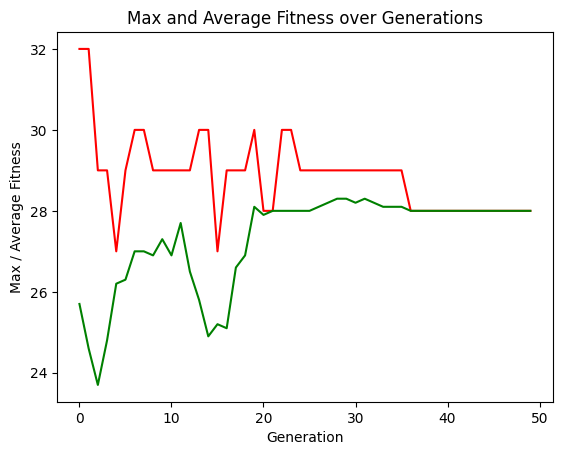

In [8]:
# Genetic Algorithm is done - plot statistics:
#sns.set_style("whitegrid")
plt.plot(maxFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Max / Average Fitness')
plt.title('Max and Average Fitness over Generations')
plt.show()

In [9]:
def run_ga(pop_size, max_gens, p_cx, p_mut, seed, verbose=False):
    random.seed(seed)
    population = toolbox.populationCreator(n=pop_size)
    for ind in population:
        ind.fitness.values = toolbox.evaluate(ind)
    fitnessValues = [ind.fitness.values[0] for ind in population]
    gen = 0
    maxF, meanF = [max(fitnessValues)], [sum(fitnessValues) / pop_size]

    while max(fitnessValues) < ONE_MAX_LENGTH and gen < max_gens:
        gen += 1
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < p_cx:
                toolbox.mate(c1, c2)
                del c1.fitness.values
                del c2.fitness.values
        for m in offspring:
            if random.random() < p_mut:
                toolbox.mutate(m)
                del m.fitness.values
        for ind in offspring:
            if not ind.fitness.valid:
                ind.fitness.values = toolbox.evaluate(ind)
        population[:] = offspring
        fitnessValues = [ind.fitness.values[0] for ind in population]
        maxF.append(max(fitnessValues))
        meanF.append(sum(fitnessValues) / pop_size)
        if verbose:
            print("- Generation {}: Max = {}, Avg = {:.2f}".format(gen, maxF[-1], meanF[-1]))

    solved = max(fitnessValues) == ONE_MAX_LENGTH
    return (gen if solved else None), maxF, meanF

- Generation 1: Max = 33.0, Avg = 25.19
- Generation 2: Max = 36.0, Avg = 26.38
- Generation 3: Max = 36.0, Avg = 27.18
- Generation 4: Max = 38.0, Avg = 28.06
- Generation 5: Max = 38.0, Avg = 28.62
- Generation 6: Max = 38.0, Avg = 29.25
- Generation 7: Max = 38.0, Avg = 29.25
- Generation 8: Max = 39.0, Avg = 29.18
- Generation 9: Max = 39.0, Avg = 29.71
- Generation 10: Max = 41.0, Avg = 29.88
- Generation 11: Max = 40.0, Avg = 30.23
- Generation 12: Max = 41.0, Avg = 30.80
- Generation 13: Max = 43.0, Avg = 31.27
- Generation 14: Max = 42.0, Avg = 32.15
- Generation 15: Max = 42.0, Avg = 32.77
- Generation 16: Max = 42.0, Avg = 33.09
- Generation 17: Max = 42.0, Avg = 33.38
- Generation 18: Max = 40.0, Avg = 33.54
- Generation 19: Max = 41.0, Avg = 33.77
- Generation 20: Max = 42.0, Avg = 33.56
- Generation 21: Max = 42.0, Avg = 33.77
- Generation 22: Max = 41.0, Avg = 34.26
- Generation 23: Max = 41.0, Avg = 34.86
- Generation 24: Max = 42.0, Avg = 35.39
- Generation 25: Max = 42

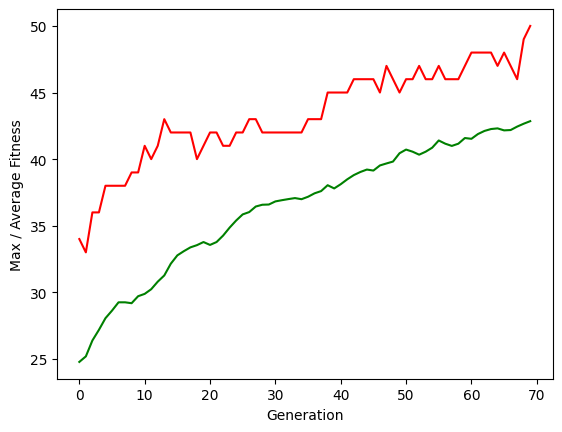

In [10]:
gens, maxF, meanF = run_ga(pop_size=120, max_gens=300, p_cx=0.9, p_mut=0.01, seed=9, verbose=True)
print("\nSolved at generation", gens)
print("Individuals processed = 120 x", gens, "=", 120 * gens)

plt.plot(maxF, color='red'); plt.plot(meanF, color='green')
plt.xlabel('Generation'); plt.ylabel('Max / Average Fitness'); plt.show()

In [11]:
for pop in [20, 50, 80, 100, 120, 150, 200, 300]:
    results = []
    for seed in range(10):
        g, _, _ = run_ga(pop, 300, 0.7, 0.01, seed)
        results.append(pop * g if g is not None else None)
    ok = [r for r in results if r is not None]
    print("pop", pop, "| solved", len(ok), "/10 | best", min(ok) if ok else "-")

pop 20 | solved 0 /10 | best -
pop 50 | solved 0 /10 | best -
pop 80 | solved 0 /10 | best -
pop 100 | solved 1 /10 | best 9100
pop 120 | solved 0 /10 | best -
pop 150 | solved 4 /10 | best 20700
pop 200 | solved 5 /10 | best 25400
pop 300 | solved 10 /10 | best 21000


In [12]:
for pop in [100, 120, 150]:
    for p_cx in [0.7, 0.9, 1.0]:
        for p_mut in [0.01, 0.1, 0.5]:
            ok = []
            for seed in range(10):
                g, _, _ = run_ga(pop, 300, p_cx, p_mut, seed)
                if g is not None:
                    ok.append(pop * g)
            print("pop", pop, "cx", p_cx, "mut", p_mut, "| solved", len(ok), "/10 | best", min(ok) if ok else "-")

pop 100 cx 0.7 mut 0.01 | solved 1 /10 | best 9100
pop 100 cx 0.7 mut 0.1 | solved 3 /10 | best 14800
pop 100 cx 0.7 mut 0.5 | solved 0 /10 | best -
pop 100 cx 0.9 mut 0.01 | solved 0 /10 | best -
pop 100 cx 0.9 mut 0.1 | solved 4 /10 | best 16700
pop 100 cx 0.9 mut 0.5 | solved 0 /10 | best -
pop 100 cx 1.0 mut 0.01 | solved 0 /10 | best -
pop 100 cx 1.0 mut 0.1 | solved 4 /10 | best 9300
pop 100 cx 1.0 mut 0.5 | solved 0 /10 | best -
pop 120 cx 0.7 mut 0.01 | solved 0 /10 | best -
pop 120 cx 0.7 mut 0.1 | solved 5 /10 | best 13080
pop 120 cx 0.7 mut 0.5 | solved 0 /10 | best -
pop 120 cx 0.9 mut 0.01 | solved 1 /10 | best 8280
pop 120 cx 0.9 mut 0.1 | solved 9 /10 | best 11880
pop 120 cx 0.9 mut 0.5 | solved 0 /10 | best -
pop 120 cx 1.0 mut 0.01 | solved 4 /10 | best 13440
pop 120 cx 1.0 mut 0.1 | solved 9 /10 | best 12840
pop 120 cx 1.0 mut 0.5 | solved 0 /10 | best -
pop 150 cx 0.7 mut 0.01 | solved 4 /10 | best 20700
pop 150 cx 0.7 mut 0.1 | solved 6 /10 | best 21450
pop 150 cx 0